# Snoozy Meditation Classifier

Binary classifier: **meditation vs. mind-wandering** from the OpenNeuro ds001787 probed EEG sessions.

Hardware target: **nRF54L15 + ADS1299-4 + BNO086** — 2-channel frontal EEG (Fp1, Fp2).

Design choices:
- 5-second window before each probe onset
- 2 EEG channels selected from the research dataset to match the wearable electrode positions (Fp1, Fp2); falls back to AF7/AF8 then F7/F8
- 64 real-time-computable features: per-channel PSD bands, sub-bands, ratios, Hjorth params, spectral entropy, ZCR + cross-channel coherence and asymmetry
- RandomForest (n=300) with class-balanced weighting
- Leave-One-Participant-Out (LOPO) cross-validation — StandardScaler fit per fold inside Pipeline to avoid leakage
- Export to ONNX for on-device inference

**Referencing note:** each ADS1299 input is wired as `FpX(+) / AFz(−)` so both channels share a common midline forehead reference. This gives the ADS1299's differential CMRR without collapsing to a single bipolar channel. The cross-channel asymmetry features (log Fp2_α − log Fp1_α, etc.) capture the same lateralization information that a hardware Fp1−Fp2 bipolar would, while keeping both channels available for per-channel features.

## Imports

In [32]:
from __future__ import annotations

import json
import math
import time
import warnings
from pathlib import Path
from typing import Dict, List, Optional, Sequence, Tuple

import joblib
import matplotlib.pyplot as plt
import mne
import numpy as np
import pandas as pd
from scipy.signal import coherence, welch
from sklearn.ensemble import RandomForestClassifier
from sklearn.impute import SimpleImputer
from sklearn.inspection import permutation_importance
from sklearn.metrics import (
    ConfusionMatrixDisplay,
    accuracy_score,
    balanced_accuracy_score,
    classification_report,
    confusion_matrix,
    f1_score,
)
from sklearn.model_selection import LeaveOneGroupOut
from sklearn.pipeline import Pipeline
from sklearn.preprocessing import StandardScaler
from sklearn.svm import SVC
from skl2onnx import convert_sklearn
from skl2onnx.common.data_types import FloatTensorType

warnings.filterwarnings("ignore", category=RuntimeWarning)
mne.set_log_level("ERROR")

## Configuration

In [33]:
DATA_ROOT = Path("dataset/ds001787")
ARTIFACTS_DIR = Path("artifacts")

# --- EEG window ---
WINDOW_SEC = 10.0       # seconds before probe onset (extended for better theta detection)
LOWCUT     = 0.5        # Hz  (bandpass pre-processing)
HIGHCUT    = 40.0       # Hz

# --- Channel selection ---
# Fp1 / Fp2 match the wearable electrode positions (PCB labels A1 / B1).
# Dataset uses standard 10-20 names confirmed in task-meditation_channels.tsv.
# AF7/AF8 are slightly less eye-blink-contaminated and better for frontal theta
# if the PCB layout ever shifts — listed first in fallbacks for that reason.
PRIMARY_CHANNELS  = ["A1", "B2"] # Fp1 and Fp2
FALLBACK_CHANNELS = ["A2", "B3"] # AF7 and AF8
N_CHANNELS_REQUIRED = 2

# --- Label mapping (Q2 response button codes from the task) ---
# Probe structure: stimulus/128 → Q1 response → Q2 response → (optional Q3)
# Q2 encodes the mind-wandering probe. Button 2 = meditating, 4/8 = mind-wandering.
Q2_LABEL: Dict[int, str] = {2: "meditation", 4: "mind_wandering", 8: "mind_wandering"}
TARGET_LABELS = ["meditation", "mind_wandering"]

# --- Spectral bands ---
BANDS = {
    "delta":  (0.5,  4.0),
    "theta":  (4.0,  8.0),
    "alpha":  (8.0, 12.0),
    "sigma":  (12.0, 16.0),
    "beta":   (16.0, 30.0),
}
# Theta and alpha sub-bands give finer resolution for meditation markers
SUB_BANDS = {
    "theta1": (4.0,  6.0),
    "theta2": (6.0,  8.0),
    "alpha1": (8.0, 10.0),
    "alpha2": (10.0, 12.0),
}

RANDOM_STATE = 42
print(f"DATA_ROOT exists: {DATA_ROOT.exists()}")

DATA_ROOT exists: True


## Feature Extraction

All features are computable in real-time from a single 5-second window on the nRF54L15 (Cortex-M33).

Feature layout (64 total):
- **Per channel × 2** (F7, F8): 5 band abs powers, 5 rel powers, 4 band ratios, 3 Hjorth, spectral entropy, ZCR, mean/std/rms, 4 sub-band powers, theta peak freq, alpha peak freq → **32 × 2 = 64** per channel
- Subtract cross-channel features from the count: **56 per-channel + 8 cross-channel = 64 total**

In [34]:
def _band_power(psd: np.ndarray, freqs: np.ndarray, lo: float, hi: float) -> float:
    mask = (freqs >= lo) & (freqs < hi)
    return float(np.sum(psd[mask])) if np.any(mask) else 0.0


def _peak_freq(psd: np.ndarray, freqs: np.ndarray, lo: float, hi: float) -> float:
    mask = (freqs >= lo) & (freqs < hi)
    if not np.any(mask):
        return (lo + hi) / 2.0
    return float(freqs[mask][np.argmax(psd[mask])])


def _spectral_entropy(psd: np.ndarray) -> float:
    p = psd / (np.sum(psd) + 1e-12)
    return float(-np.sum(p * np.log(p + 1e-12)))


def _hjorth(x: np.ndarray) -> Tuple[float, float, float]:
    """Activity, Mobility, Complexity."""
    activity = float(np.var(x))
    d1 = np.diff(x)
    mobility = float(np.sqrt(np.var(d1) / (activity + 1e-12)))
    d2 = np.diff(d1)
    mob_d1 = float(np.sqrt(np.var(d2) / (np.var(d1) + 1e-12)))
    complexity = mob_d1 / (mobility + 1e-12)
    return activity, mobility, complexity


def channel_features(x: np.ndarray, fs: float) -> List[float]:
    """28 features from a single EEG channel."""
    x = x.astype(np.float64)
    nperseg = min(int(fs), len(x))           # 1-second segments for Welch
    freqs, psd = welch(x, fs=fs, nperseg=nperseg)
    total_power = float(np.sum(psd)) + 1e-12

    band_abs = {name: _band_power(psd, freqs, lo, hi) for name, (lo, hi) in BANDS.items()}
    band_rel = {name: v / total_power for name, v in band_abs.items()}

    feats: List[float] = []

    # 5 absolute + 5 relative band powers
    for name in BANDS:
        feats.append(band_abs[name])
    for name in BANDS:
        feats.append(band_rel[name])

    # 4 band ratios (key meditation markers)
    theta, alpha = band_abs["theta"], band_abs["alpha"]
    delta, beta   = band_abs["delta"],  band_abs["beta"]
    feats.append(theta / (alpha + 1e-12))      # theta/alpha
    feats.append(delta / (beta  + 1e-12))      # delta/beta
    feats.append(alpha / (beta  + 1e-12))      # alpha/beta
    feats.append(theta / (beta  + 1e-12))      # theta/beta

    # Hjorth (activity, mobility, complexity)
    feats.extend(_hjorth(x))

    # Spectral entropy
    feats.append(_spectral_entropy(psd))

    # Zero-crossing rate
    feats.append(float(np.mean(np.diff(np.signbit(x)) != 0)))

    # Time domain: mean, std, rms
    feats.append(float(np.mean(x)))
    feats.append(float(np.std(x)))
    feats.append(float(np.sqrt(np.mean(x ** 2))))

    # 4 sub-band absolute powers (theta1, theta2, alpha1, alpha2)
    for lo, hi in SUB_BANDS.values():
        feats.append(_band_power(psd, freqs, lo, hi))

    # Peak frequencies in theta and alpha bands
    feats.append(_peak_freq(psd, freqs, *BANDS["theta"]))
    feats.append(_peak_freq(psd, freqs, *BANDS["alpha"]))

    return feats  # 5+5+4+3+1+1+3+4+2 = 28


def cross_channel_features(eeg: np.ndarray, fs: float) -> List[float]:
    """8 cross-channel features for a 2-channel EEG array (shape: 2 × samples)."""
    assert eeg.shape[0] == 2, f"Expected 2 channels, got {eeg.shape[0]}"
    ch0, ch1 = eeg[0].astype(np.float64), eeg[1].astype(np.float64)
    nperseg = min(int(fs), eeg.shape[1])

    feats: List[float] = []

    # Coherence in theta, alpha, beta bands (mean within each band)
    for band_name in ("theta", "alpha", "beta"):
        lo, hi = BANDS[band_name]
        f_coh, cxy = coherence(ch0, ch1, fs=fs, nperseg=nperseg)
        mask = (f_coh >= lo) & (f_coh < hi)
        feats.append(float(np.mean(cxy[mask])) if np.any(mask) else 0.0)

    # Broadband Pearson correlation
    corr = float(np.corrcoef(ch0, ch1)[0, 1])
    feats.append(corr if np.isfinite(corr) else 0.0)

    # Alpha and theta power asymmetry: log(R) - log(L)
    _, psd0 = welch(ch0, fs=fs, nperseg=nperseg)
    _, psd1 = welch(ch1, fs=fs, nperseg=nperseg)
    freqs, _ = welch(ch0, fs=fs, nperseg=nperseg)

    for band_name in ("alpha", "theta", "delta", "beta"):
        lo, hi = BANDS[band_name]
        p0 = _band_power(psd0, freqs, lo, hi)
        p1 = _band_power(psd1, freqs, lo, hi)
        # log asymmetry (F8 - F7), a lateralization marker
        feats.append(float(np.log(p1 + 1e-12) - np.log(p0 + 1e-12)))

    return feats  # 3 coherence + 1 corr + 4 asymmetry = 8


def extract_features(eeg: np.ndarray, fs: float) -> np.ndarray:
    """Full feature vector for a 2-channel EEG epoch (shape: 2 × samples) → 64 floats."""
    feats: List[float] = []
    for ch in range(eeg.shape[0]):
        feats.extend(channel_features(eeg[ch], fs))
    feats.extend(cross_channel_features(eeg, fs))
    return np.asarray(feats, dtype=np.float32)


def feature_names(ch_names: Sequence[str]) -> List[str]:
    """Ordered list of feature names matching extract_features output."""
    names: List[str] = []
    for ch in ch_names:
        for band in BANDS:
            names.append(f"{ch}_{band}_abs")
        for band in BANDS:
            names.append(f"{ch}_{band}_rel")
        names += [f"{ch}_theta_alpha", f"{ch}_delta_beta", f"{ch}_alpha_beta", f"{ch}_theta_beta"]
        names += [f"{ch}_hjorth_act", f"{ch}_hjorth_mob", f"{ch}_hjorth_cplx"]
        names.append(f"{ch}_spec_entropy")
        names.append(f"{ch}_zcr")
        names += [f"{ch}_mean", f"{ch}_std", f"{ch}_rms"]
        for sub in SUB_BANDS:
            names.append(f"{ch}_{sub}_abs")
        names.append(f"{ch}_theta_peak_hz")
        names.append(f"{ch}_alpha_peak_hz")
    ch0, ch1 = ch_names[0], ch_names[1]
    names += ["coh_theta", "coh_alpha", "coh_beta", "corr_broadband"]
    names += [f"asym_alpha_{ch1}_{ch0}", f"asym_theta_{ch1}_{ch0}",
               f"asym_delta_{ch1}_{ch0}", f"asym_beta_{ch1}_{ch0}"]
    return names


# Smoke-test: confirm expected dimensionality
_dummy_eeg = np.random.randn(2, int(256 * WINDOW_SEC)).astype(np.float32)
_dummy_feats = extract_features(_dummy_eeg, fs=256.0)
_dummy_names = feature_names(["F7", "F8"])
print(f"Feature vector length : {len(_dummy_feats)}")
print(f"Feature names length  : {len(_dummy_names)}")
assert len(_dummy_feats) == len(_dummy_names), "Feature count mismatch!"
print("Feature extraction OK")

Feature vector length : 64
Feature names length  : 64
Feature extraction OK


## Dataset Loading

Selects F7 and F8 from each recording. Falls back to the best-available frontal pair if either channel is missing.

Probe label extraction follows the Q2 convention: stimulus/128 → responses → Q2 is the second response value (2=meditation, 4/8=mind_wandering). Adapted from `med_model.py`.

In [35]:
def _pick_two_channels(raw: mne.io.BaseRaw) -> Optional[List[str]]:
    """Return two channel names that best approximate the wearable electrode positions."""
    eeg_picks = mne.pick_types(raw.info, eeg=True, exclude="bads")
    available = {raw.ch_names[i] for i in eeg_picks}

    if all(ch in available for ch in PRIMARY_CHANNELS):
        return list(PRIMARY_CHANNELS)

    chosen: List[str] = []
    for wanted in PRIMARY_CHANNELS:
        if wanted in available:
            chosen.append(wanted)
        else:
            for fb in FALLBACK_CHANNELS:
                if fb in available and fb not in chosen:
                    chosen.append(fb)
                    break

    return chosen if len(chosen) >= N_CHANNELS_REQUIRED else None


def _extract_probe_label(events_df: pd.DataFrame, probe_idx: int) -> Optional[str]:
    """Q2 label from the response rows that follow a probe onset."""
    responses: List[int] = []
    for j in range(probe_idx + 1, len(events_df)):
        row = events_df.iloc[j]
        tt = str(row.get("trial_type", "")).strip().lower()
        val = row.get("value")
        if tt == "stimulus" and pd.notna(val) and int(val) == 128:
            break
        if tt == "response" and pd.notna(val) and int(val) in Q2_LABEL:
            responses.append(int(val))
        if len(responses) == 3:
            break
    if len(responses) < 2:
        return None
    return Q2_LABEL.get(responses[1])


def _find_recording_pairs(sub_dir: Path) -> List[Tuple[Path, Path]]:
    """
    Walk sub-XX/ses-XX/eeg/ and return (eeg_file, events_tsv) pairs.
    Structure: sub_dir / ses-* / eeg / *_task-meditation_eeg.{bdf,edf,...}
    """
    pairs: List[Tuple[Path, Path]] = []
    for ses_dir in sorted(sub_dir.glob("ses-*")):
        if not ses_dir.is_dir():
            continue
        eeg_dir = ses_dir / "eeg"
        if not eeg_dir.is_dir():
            continue
        for eeg_path in sorted(eeg_dir.iterdir()):
            if eeg_path.suffix.lower() not in {".edf", ".bdf", ".set", ".fif"}:
                continue
            if "task-meditation" not in eeg_path.name:
                continue
            if f"_eeg{eeg_path.suffix}" not in eeg_path.name:
                continue
            events_path = eeg_path.with_name(
                eeg_path.name.replace(f"_eeg{eeg_path.suffix}", "_events.tsv")
            )
            if events_path.exists():
                pairs.append((eeg_path, events_path))
    return pairs


def _read_raw(eeg_path: Path) -> mne.io.BaseRaw:
    readers = {".edf": mne.io.read_raw_edf, ".bdf": mne.io.read_raw_bdf,
               ".set": mne.io.read_raw_eeglab, ".fif": mne.io.read_raw_fif}
    fn = readers.get(eeg_path.suffix.lower())
    if fn is None:
        raise ValueError(f"Unsupported format: {eeg_path.suffix}")
    return fn(eeg_path, preload=True, verbose="ERROR")


def load_dataset(
    ds_root: Path,
    window_sec: float = WINDOW_SEC,
    max_subjects: Optional[int] = None,
) -> Tuple[np.ndarray, np.ndarray, np.ndarray, List[str], float]:
    """
    Returns X (n_epochs × n_features), y (n_epochs,), groups (n_epochs,),
    channel_names, sampling_freq.
    """
    subject_dirs = sorted(p for p in ds_root.glob("sub-*") if p.is_dir())
    if max_subjects is not None:
        subject_dirs = subject_dirs[:max_subjects]

    canonical_channels: Optional[List[str]] = None
    canonical_sfreq:    Optional[float]     = None

    all_X:      List[np.ndarray] = []
    all_y:      List[str]        = []
    all_groups: List[str]        = []

    for sub_dir in subject_dirs:
        pairs = _find_recording_pairs(sub_dir)
        if not pairs:
            print(f"  skip {sub_dir.name}: no meditation EEG pairs")
            continue

        subj_kept = 0
        for eeg_path, events_path in pairs:
            try:
                raw = _read_raw(eeg_path)
            except Exception as exc:
                print(f"  skip {eeg_path.name}: {exc}")
                continue

            ch_sel = _pick_two_channels(raw)
            if ch_sel is None:
                print(f"  skip {eeg_path.name}: could not find 2 frontal channels")
                continue

            if canonical_channels is None:
                canonical_channels = ch_sel
            else:
                ch_sel = canonical_channels
                if not all(c in raw.ch_names for c in ch_sel):
                    print(f"  skip {eeg_path.name}: canonical channels not present")
                    continue

            raw.pick(ch_sel)
            raw.filter(LOWCUT, HIGHCUT, verbose="ERROR")

            sfreq = float(raw.info["sfreq"])
            if canonical_sfreq is None:
                canonical_sfreq = sfreq
            elif abs(sfreq - canonical_sfreq) > 1e-6:
                raw.resample(canonical_sfreq, npad="auto")
                sfreq = canonical_sfreq

            window_samples = int(round(window_sec * sfreq))

            try:
                events_df = pd.read_csv(events_path, sep="\t")
            except Exception as exc:
                print(f"  skip {events_path.name}: {exc}")
                continue

            if not {"onset", "trial_type", "value"}.issubset(events_df.columns):
                print(f"  skip {events_path.name}: missing required columns")
                continue

            for i, row in events_df.iterrows():
                tt  = str(row.get("trial_type", "")).strip().lower()
                val = row.get("value")
                if tt != "stimulus" or pd.isna(val) or int(val) != 128:
                    continue

                label = _extract_probe_label(events_df, i)
                if label not in TARGET_LABELS:
                    continue

                stop_sample  = int(round(float(row["onset"]) * sfreq))
                start_sample = stop_sample - window_samples
                if start_sample < 0 or stop_sample > raw.n_times:
                    continue

                segment = raw.get_data(start=start_sample, stop=stop_sample).astype(np.float32)
                if segment.shape != (len(ch_sel), window_samples):
                    continue

                feat_vec = extract_features(segment, fs=sfreq)
                all_X.append(feat_vec)
                all_y.append(label)
                all_groups.append(sub_dir.name)
                subj_kept += 1

        print(f"  {sub_dir.name}: {subj_kept} epochs")

    if not all_X:
        raise ValueError("No usable epochs found — check DATA_ROOT and channel names")

    X = np.vstack(all_X).astype(np.float32)
    y = np.asarray(all_y)
    groups = np.asarray(all_groups)

    print(f"\nLoaded {len(y)} epochs from {len(np.unique(groups))} subjects")
    print(f"Class counts: {pd.Series(y).value_counts().to_dict()}")
    print(f"Channels: {canonical_channels}  |  fs: {canonical_sfreq} Hz")
    return X, y, groups, canonical_channels, canonical_sfreq

In [36]:
print("Loading dataset...")
X, y, groups, channel_names, fs = load_dataset(DATA_ROOT)

n_features = X.shape[1]
feat_names = feature_names(channel_names)
print(f"Feature matrix: {X.shape}  |  features: {n_features}")

Loading dataset...
  sub-001: 53 epochs
  sub-002: 54 epochs
  sub-003: 28 epochs
  sub-004: 13 epochs
  sub-005: 36 epochs
  sub-006: 46 epochs
  sub-007: 40 epochs
  sub-008: 24 epochs
  sub-009: 32 epochs
  sub-010: 48 epochs
  sub-011: 52 epochs
  sub-012: 28 epochs
  sub-013: 19 epochs
  sub-014: 12 epochs
  sub-015: 25 epochs
  sub-016: 23 epochs
  sub-017: 30 epochs
  sub-018: 55 epochs
  sub-019: 29 epochs
  sub-020: 25 epochs
  sub-021: 33 epochs
  sub-022: 22 epochs
  sub-023: 35 epochs
  sub-024: 42 epochs

Loaded 804 epochs from 24 subjects
Class counts: {'meditation': 503, 'mind_wandering': 301}
Channels: ['A1', 'B2']  |  fs: 256.0 Hz
Feature matrix: (804, 64)  |  features: 64


## Model & LOPO Cross-Validation

Pipeline: `SimpleImputer → StandardScaler → RandomForestClassifier`

The scaler is fit **only on training folds**, so no test-set leakage. LOPO uses all subjects as held-out test subjects in turn.

In [63]:
def make_pipeline() -> Pipeline:
    return Pipeline([
        ("imputer", SimpleImputer(strategy="median")),
        ("scaler",  StandardScaler()),
        ("clf", SVC(
            kernel="rbf",
            class_weight="balanced",
            C=1.0,
            probability=True,
            random_state=RANDOM_STATE,
        )),
    ])

In [64]:
def run_lopo(
    X: np.ndarray, y: np.ndarray, groups: np.ndarray
) -> Tuple[List[dict], List[str], List[str], List[float]]:
    logo = LeaveOneGroupOut()
    fold_results: List[dict]  = []
    y_true_all:   List[str]   = []
    y_pred_all:   List[str]   = []
    y_proba_all:  List[float] = []

    for fold_idx, (train_idx, test_idx) in enumerate(
        logo.split(X, y, groups), start=1
    ):
        held_out = str(groups[test_idx][0])

        # Skip single-class test sets — balanced metrics are undefined
        if len(np.unique(y[test_idx])) < len(TARGET_LABELS):
            print(f"  Fold {fold_idx:2d} | held-out: {held_out} | skipped (single-class test set)")
            continue

        model = make_pipeline()
        model.fit(X[train_idx], y[train_idx])
        y_pred  = model.predict(X[test_idx])
        med_idx = list(model.classes_).index("meditation")
        y_proba = model.predict_proba(X[test_idx])[:, med_idx]

        fold_results.append({
            "fold":         fold_idx,
            "held_out":     held_out,
            "n_train":      int(len(train_idx)),
            "n_test":       int(len(test_idx)),
            "accuracy":     float(accuracy_score(y[test_idx], y_pred)),
            "balanced_acc": float(balanced_accuracy_score(y[test_idx], y_pred)),
            "f1_macro":     float(f1_score(y[test_idx], y_pred, average="macro", zero_division=0)),
        })
        y_true_all.extend(y[test_idx].tolist())
        y_pred_all.extend(y_pred.tolist())
        y_proba_all.extend(y_proba.tolist())

        print(f"  Fold {fold_idx:2d} | held-out: {held_out} | "
              f"acc={fold_results[-1]['accuracy']:.3f} | "
              f"bal_acc={fold_results[-1]['balanced_acc']:.3f} | "
              f"F1={fold_results[-1]['f1_macro']:.3f}")

    return fold_results, y_true_all, y_pred_all, y_proba_all


print("Running LOPO cross-validation...")
fold_results, y_true, y_pred, y_proba = run_lopo(X, y, groups)

Running LOPO cross-validation...
  Fold  1 | held-out: sub-001 | acc=0.566 | bal_acc=0.464 | F1=0.429
  Fold  2 | held-out: sub-002 | acc=0.630 | bal_acc=0.483 | F1=0.464
  Fold  3 | held-out: sub-003 | acc=0.321 | bal_acc=0.548 | F1=0.299
  Fold  4 | held-out: sub-004 | acc=0.385 | bal_acc=0.250 | F1=0.278
  Fold  5 | held-out: sub-005 | acc=0.333 | bal_acc=0.479 | F1=0.278
  Fold  6 | held-out: sub-006 | acc=0.783 | bal_acc=0.500 | F1=0.439
  Fold  7 | held-out: sub-007 | acc=0.800 | bal_acc=0.539 | F1=0.543
  Fold  8 | held-out: sub-008 | acc=0.792 | bal_acc=0.688 | F1=0.705
  Fold  9 | held-out: sub-009 | acc=0.375 | bal_acc=0.677 | F1=0.307
  Fold 10 | held-out: sub-010 | acc=0.500 | bal_acc=0.490 | F1=0.486
  Fold 11 | held-out: sub-011 | acc=0.654 | bal_acc=0.557 | F1=0.538
  Fold 12 | held-out: sub-012 | acc=0.107 | bal_acc=0.500 | F1=0.097
  Fold 13 | held-out: sub-013 | acc=0.842 | bal_acc=0.500 | F1=0.457
  Fold 14 | held-out: sub-014 | skipped (single-class test set)
  Fold

## Results

In [65]:
folds_df = pd.DataFrame(fold_results)

print("=" * 55)
print("LOPO Cross-Validation Summary")
print("=" * 55)
print(f"Subjects:          {len(folds_df)}")
print(f"Accuracy:          {folds_df['accuracy'].mean():.3f} ± {folds_df['accuracy'].std():.3f}")
print(f"Balanced accuracy: {folds_df['balanced_acc'].mean():.3f} ± {folds_df['balanced_acc'].std():.3f}")
print(f"F1 macro:          {folds_df['f1_macro'].mean():.3f} ± {folds_df['f1_macro'].std():.3f}")
print()
print(classification_report(y_true, y_pred, target_names=TARGET_LABELS, zero_division=0))

folds_df

LOPO Cross-Validation Summary
Subjects:          23
Accuracy:          0.544 ± 0.197
Balanced accuracy: 0.536 ± 0.110
F1 macro:          0.426 ± 0.147

                precision    recall  f1-score   support

    meditation       0.64      0.65      0.64       491
mind_wandering       0.41      0.40      0.40       301

      accuracy                           0.55       792
     macro avg       0.52      0.52      0.52       792
  weighted avg       0.55      0.55      0.55       792



,fold,held_out,n_train,n_test,accuracy,balanced_acc,f1_macro
0,1,sub-001,751,53,0.566038,0.464396,0.428504
1,2,sub-002,750,54,0.629630,0.483283,0.464286
2,3,sub-003,776,28,0.321429,0.547619,0.299078
3,4,sub-004,791,13,0.384615,0.250000,0.277778
4,5,sub-005,768,36,0.333333,0.479167,0.277592
5,6,sub-006,758,46,0.782609,0.500000,0.439024
6,7,sub-007,764,40,0.800000,0.539216,0.542857
7,8,sub-008,780,24,0.791667,0.687500,0.705160
8,9,sub-009,772,32,0.375000,0.677419,0.307359
9,10,sub-010,756,48,0.500000,0.489510,0.485714


Computing permutation importance (may take ~1 min)...


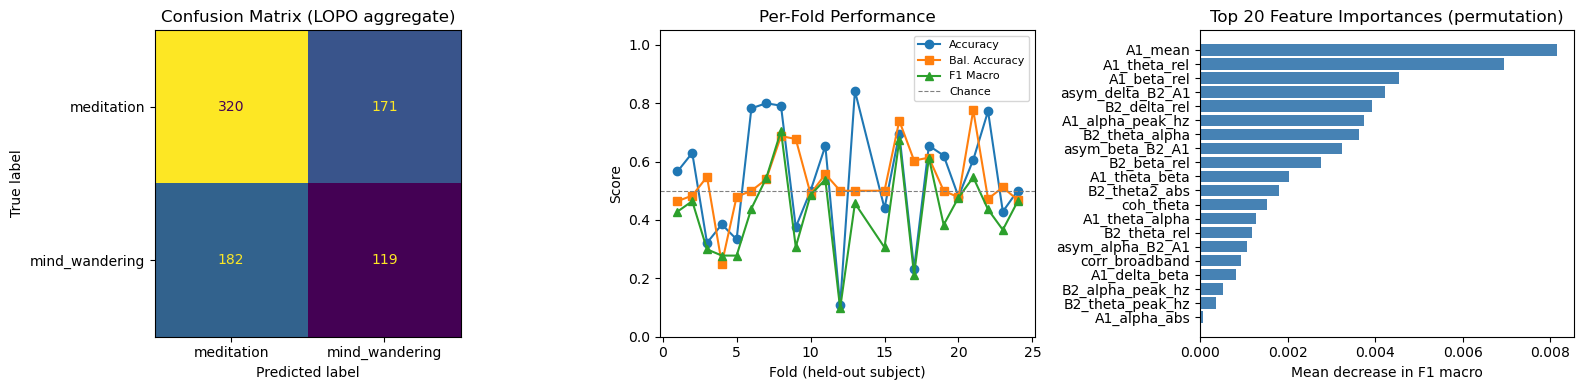

Saved lopo_results.png


In [66]:
fig, axes = plt.subplots(1, 3, figsize=(16, 4))

# Confusion matrix
cm = confusion_matrix(y_true, y_pred, labels=TARGET_LABELS)
ConfusionMatrixDisplay(cm, display_labels=TARGET_LABELS).plot(ax=axes[0], colorbar=False)
axes[0].set_title("Confusion Matrix (LOPO aggregate)")

# Per-fold metrics
axes[1].plot(folds_df["fold"], folds_df["accuracy"],     "o-", label="Accuracy")
axes[1].plot(folds_df["fold"], folds_df["balanced_acc"], "s-", label="Bal. Accuracy")
axes[1].plot(folds_df["fold"], folds_df["f1_macro"],     "^-", label="F1 Macro")
axes[1].axhline(0.5, color="gray", linestyle="--", linewidth=0.8, label="Chance")
axes[1].set_xlabel("Fold (held-out subject)")
axes[1].set_ylabel("Score")
axes[1].set_title("Per-Fold Performance")
axes[1].legend(fontsize=8)
axes[1].set_ylim(0, 1.05)

# Feature importance via permutation (model-agnostic, works for SVC)
print("Computing permutation importance (may take ~1 min)...")
final_model = make_pipeline()
final_model.fit(X, y)
perm = permutation_importance(
    final_model, X, y,
    n_repeats=5, random_state=RANDOM_STATE, n_jobs=-1, scoring="f1_macro",
)
importances = perm.importances_mean
top_n  = 20
top_idx = np.argsort(importances)[::-1][:top_n]
axes[2].barh([feat_names[i] for i in top_idx[::-1]],
             importances[top_idx[::-1]], color="steelblue")
axes[2].set_title(f"Top {top_n} Feature Importances (permutation)")
axes[2].set_xlabel("Mean decrease in F1 macro")

plt.tight_layout()
ARTIFACTS_DIR.mkdir(parents=True, exist_ok=True)
plt.savefig(ARTIFACTS_DIR / "lopo_results.png", dpi=150, bbox_inches="tight")
plt.show()
print("Saved lopo_results.png")

## Threshold Tuning

SVC with `probability=True` outputs calibrated probabilities. The default threshold of 0.5 often underpredicts the minority class. Sweeping the threshold using the LOPO-collected probabilities finds the value that maximises F1 macro without re-training.

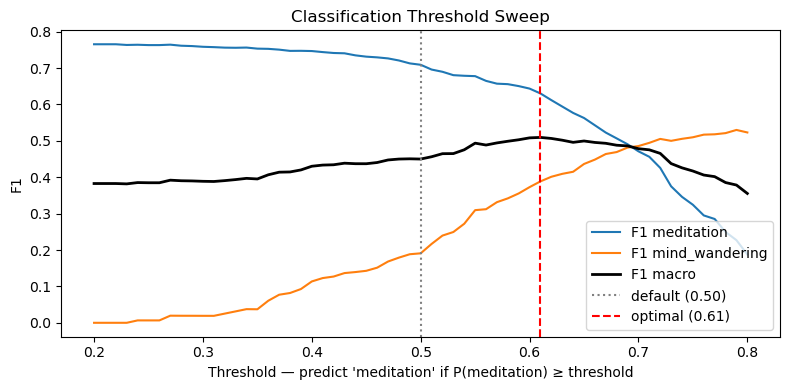

Default  threshold (0.50) → F1 macro: 0.450
Optimal  threshold (0.61) → F1 macro: 0.509  (+0.059)


In [67]:
# Sweep classification threshold using LOPO-collected probabilities.
# Default threshold (0.5) may underpredict meditation — tuning balances per-class F1.
thresholds = np.linspace(0.2, 0.8, 61)
f1_med, f1_mw, f1_mac = [], [], []
y_proba_arr = np.array(y_proba)

for t in thresholds:
    y_pred_t = np.where(y_proba_arr >= t, "meditation", "mind_wandering")
    f1_med.append(f1_score(y_true, y_pred_t, pos_label="meditation",     zero_division=0))
    f1_mw.append( f1_score(y_true, y_pred_t, pos_label="mind_wandering", zero_division=0))
    f1_mac.append(f1_score(y_true, y_pred_t, average="macro",            zero_division=0))

best_t   = thresholds[np.argmax(f1_mac)]
best_f1  = max(f1_mac)
default_f1 = f1_mac[np.argmin(np.abs(thresholds - 0.5))]

fig, ax = plt.subplots(figsize=(8, 4))
ax.plot(thresholds, f1_med, label="F1 meditation")
ax.plot(thresholds, f1_mw,  label="F1 mind_wandering")
ax.plot(thresholds, f1_mac, label="F1 macro", linewidth=2, color="black")
ax.axvline(0.5,    color="gray", linestyle=":",  label="default (0.50)")
ax.axvline(best_t, color="red",  linestyle="--", label=f"optimal ({best_t:.2f})")
ax.set_xlabel("Threshold — predict 'meditation' if P(meditation) ≥ threshold")
ax.set_ylabel("F1")
ax.set_title("Classification Threshold Sweep")
ax.legend()
plt.tight_layout()
plt.savefig(ARTIFACTS_DIR / "threshold_curve.png", dpi=150, bbox_inches="tight")
plt.show()

print(f"Default  threshold (0.50) → F1 macro: {default_f1:.3f}")
print(f"Optimal  threshold ({best_t:.2f}) → F1 macro: {best_f1:.3f}  (+{best_f1 - default_f1:.3f})")

## Real-Time Benchmark

Measure feature extraction and SVM inference time on this machine, then estimate latency on the nRF54L15 (Cortex-M33 @ 128 MHz) using known CMSIS-DSP cycle counts for `arm_rfft_fast_f32`.

In [68]:
# Benchmark feature extraction to show real-time viability on nRF54L15 (Cortex-M33)
sample_seg = np.random.randn(2, int(fs * WINDOW_SEC)).astype(np.float32)

N = 200
t0 = time.perf_counter()
for _ in range(N):
    extract_features(sample_seg, fs)
pc_ms = (time.perf_counter() - t0) / N * 1000

# Time the SVM inference step separately
N_inf = 500
sample_feat = extract_features(sample_seg, fs).reshape(1, -1)
t0 = time.perf_counter()
for _ in range(N_inf):
    final_model.predict_proba(sample_feat)
infer_ms = (time.perf_counter() - t0) / N_inf * 1000

# nRF54L15 Cortex-M33 @ 128 MHz estimate with CMSIS-DSP
# arm_rfft_fast_f32(256) ≈ 1000 cycles ≈ 8 µs at 128 MHz
# Welch on WINDOW_SEC window: ~ceil(2*WINDOW_SEC) segments × 2 channels
n_segments   = math.ceil(2 * WINDOW_SEC)
fft_us       = n_segments * 2 * 8       # FFT calls × channels × 8 µs
scalar_us    = 200                       # band sums, Hjorth, ratios, ZCR, log-asymmetry
svm_us       = 800                       # O(n_support × n_features), ~few hundred µs
m33_total_ms = (fft_us + scalar_us + svm_us) / 1000

budget_ms = WINDOW_SEC * 1000
headroom  = budget_ms - m33_total_ms

print(f"Feature extraction  PC (Python):         {pc_ms:.1f} ms")
print(f"SVM inference       PC (Python):         {infer_ms:.2f} ms")
print(f"")
print(f"M33 estimate (CMSIS-DSP arm_rfft_fast_f32):")
print(f"  FFT  ({n_segments} segs × 2 ch × 8 µs):         {fft_us} µs")
print(f"  Scalar ops (bands, Hjorth, ratios, ZCR): {scalar_us} µs")
print(f"  SVM inference:                           {svm_us} µs")
print(f"  Total:                                   {m33_total_ms:.1f} ms")
print(f"")
print(f"Window budget:  {budget_ms:.0f} ms")
print(f"Headroom:       {headroom:.0f} ms  ({headroom/budget_ms*100:.0f}% of budget remaining)")
print(f"Real-time viable: {'YES' if headroom > 0 else 'NO'}")

Feature extraction  PC (Python):         9.4 ms
SVM inference       PC (Python):         1.35 ms

M33 estimate (CMSIS-DSP arm_rfft_fast_f32):
  FFT  (20 segs × 2 ch × 8 µs):         320 µs
  Scalar ops (bands, Hjorth, ratios, ZCR): 200 µs
  SVM inference:                           800 µs
  Total:                                   1.3 ms

Window budget:  10000 ms
Headroom:       9999 ms  (100% of budget remaining)
Real-time viable: YES


## Firmware-Viable Feature Set

Drop the 3 coherence features (`coh_theta`, `coh_alpha`, `coh_beta`): they require cross-spectrum computation (`arm_cmplx_mult_cmplx_f32` + magnitude-squared per bin), which is non-trivial firmware code. Lateralization is already captured by the log-asymmetry features (`asym_*`), which are just `log(P_Fp2) − log(P_Fp1)` computed from band powers already in hand.

All remaining 61 features use only `arm_rfft_fast_f32` + scalar arithmetic (`CONFIG_CMSIS_DSP=y`).

In [69]:
# Coherence requires simultaneous FFT on both channels + cross-spectrum multiplication —
# significant firmware complexity vs. log-asymmetry which is just log(P_R) - log(P_L).
FW_EXCLUDE = {"coh_theta", "coh_alpha", "coh_beta"}

fw_feat_names = [n for n in feat_names if n not in FW_EXCLUDE]
fw_mask       = np.array([n not in FW_EXCLUDE for n in feat_names])
X_fw          = X[:, fw_mask]

print(f"Full model:     {len(feat_names)} features")
print(f"Firmware model: {len(fw_feat_names)} features  (dropped: {sorted(FW_EXCLUDE)})")
print()

print("Running LOPO for firmware feature set...")
fw_fold_results, fw_y_true, fw_y_pred, _ = run_lopo(X_fw, y, groups)
fw_df = pd.DataFrame(fw_fold_results)

print()
print(f"{'Metric':<20} {'Full model':>12} {'Firmware':>10} {'Delta':>8}")
print("-" * 52)
for col, label in [("accuracy", "Accuracy"), ("balanced_acc", "Balanced Acc"), ("f1_macro", "F1 Macro")]:
    full_val = folds_df[col].mean()
    fw_val   = fw_df[col].mean()
    print(f"{label:<20} {full_val:>12.3f} {fw_val:>10.3f} {fw_val - full_val:>+8.3f}")

Full model:     64 features
Firmware model: 61 features  (dropped: ['coh_alpha', 'coh_beta', 'coh_theta'])

Running LOPO for firmware feature set...
  Fold  1 | held-out: sub-001 | acc=0.604 | bal_acc=0.482 | F1=0.417
  Fold  2 | held-out: sub-002 | acc=0.630 | bal_acc=0.483 | F1=0.464
  Fold  3 | held-out: sub-003 | acc=0.321 | bal_acc=0.548 | F1=0.299
  Fold  4 | held-out: sub-004 | acc=0.462 | bal_acc=0.417 | F1=0.405
  Fold  5 | held-out: sub-005 | acc=0.333 | bal_acc=0.458 | F1=0.299
  Fold  6 | held-out: sub-006 | acc=0.804 | bal_acc=0.550 | F1=0.535
  Fold  7 | held-out: sub-007 | acc=0.775 | bal_acc=0.525 | F1=0.526
  Fold  8 | held-out: sub-008 | acc=0.667 | bal_acc=0.594 | F1=0.597
  Fold  9 | held-out: sub-009 | acc=0.344 | bal_acc=0.661 | F1=0.287
  Fold 10 | held-out: sub-010 | acc=0.500 | bal_acc=0.490 | F1=0.486
  Fold 11 | held-out: sub-011 | acc=0.654 | bal_acc=0.557 | F1=0.538
  Fold 12 | held-out: sub-012 | acc=0.214 | bal_acc=0.413 | F1=0.210
  Fold 13 | held-out: s

In [70]:
# Train final firmware model on reduced feature set and export
fw_final = make_pipeline()
fw_final.fit(X_fw, y)
n_fw_features = len(fw_feat_names)

fw_onnx = convert_sklearn(
    fw_final,
    initial_types=[("input", FloatTensorType([None, n_fw_features]))],
)
fw_onnx_path = ARTIFACTS_DIR / "meditation_model_fw.onnx"
fw_onnx_path.write_bytes(fw_onnx.SerializeToString())

fw_schema = {
    "input_name":    "input",
    "dtype":         "float32",
    "window_sec":    WINDOW_SEC,
    "sampling_rate_hz": float(fs),
    "channel_names": list(channel_names),
    "n_features":    n_fw_features,
    "feature_names": fw_feat_names,
    "excluded_vs_full": sorted(FW_EXCLUDE),
    "zephyr_note": (
        "All features computable with CONFIG_CMSIS_DSP=y. "
        "Use arm_rfft_fast_f32(256) for Welch PSD segments, then scalar band summation. "
        "Coherence dropped — lateralization captured by log-asymmetry features instead."
    ),
    "outputs": TARGET_LABELS,
}
fw_schema_path = ARTIFACTS_DIR / "feature_schema_fw.json"
fw_schema_path.write_text(json.dumps(fw_schema, indent=2), encoding="utf-8")
print(f"Firmware ONNX saved:   {fw_onnx_path}")
print(f"Firmware schema saved: {fw_schema_path}")

Firmware ONNX saved:   artifacts\meditation_model_fw.onnx
Firmware schema saved: artifacts\feature_schema_fw.json


## Export — ONNX Model & Feature Schema

In [71]:
# ONNX export
onnx_model = convert_sklearn(
    final_model,
    initial_types=[("input", FloatTensorType([None, n_features]))],
)
onnx_path = ARTIFACTS_DIR / "meditation_model_snoozy.onnx"
onnx_path.write_bytes(onnx_model.SerializeToString())
print(f"ONNX model saved: {onnx_path}")

# Joblib export (for quick Python inference during development)
joblib_path = ARTIFACTS_DIR / "meditation_model_snoozy.joblib"
joblib.dump(final_model, joblib_path)
print(f"Joblib model saved: {joblib_path}")

# Feature schema for the Snoozy firmware / app
schema = {
    "input_name": "input",
    "dtype": "float32",
    "window_sec": WINDOW_SEC,
    "sampling_rate_hz": float(fs),
    "channel_names": list(channel_names),
    "channel_mapping": {
        channel_names[0]: "Fp1",
        channel_names[1]: "Fp2",
    },
    "hardware_referencing": (
        "Each ADS1299 channel is wired differentially: FpX(+) vs AFz(-). "
        "AFz (midline forehead) is the common reference for both channels. "
        "Do NOT collapse to a single Fp1-Fp2 bipolar — asymmetry features "
        "require both channels separately."
    ),
    "n_features": n_features,
    "feature_names": feat_names,
    "bands_hz": {k: list(v) for k, v in BANDS.items()},
    "sub_bands_hz": {k: list(v) for k, v in SUB_BANDS.items()},
    "bandpass_hz": [LOWCUT, HIGHCUT],
    "outputs": TARGET_LABELS,
    "lopo_cv": {
        "mean_accuracy":     float(folds_df["accuracy"].mean()),
        "std_accuracy":      float(folds_df["accuracy"].std()),
        "mean_balanced_acc": float(folds_df["balanced_acc"].mean()),
        "mean_f1_macro":     float(folds_df["f1_macro"].mean()),
        "n_subjects":        int(len(folds_df)),
    },
    "notes": (
        "Binary meditation vs. mind_wandering classifier for Snoozy (nRF54L15 + ADS1299-4). "
        "Input to ONNX is the engineered feature vector, not raw EEG. "
        "Features are extracted from the 5-second EEG window. "
        "Trained on OpenNeuro ds001787 with LOPO CV."
    ),
}

schema_path = ARTIFACTS_DIR / "feature_schema_snoozy.json"
schema_path.write_text(json.dumps(schema, indent=2), encoding="utf-8")
print(f"Feature schema saved: {schema_path}")

ONNX model saved: artifacts\meditation_model_snoozy.onnx
Joblib model saved: artifacts\meditation_model_snoozy.joblib
Feature schema saved: artifacts\feature_schema_snoozy.json


## Sanity Check — ONNX Inference

In [72]:
import onnxruntime as ort

sess = ort.InferenceSession(str(onnx_path))
input_name  = sess.get_inputs()[0].name
output_name = sess.get_outputs()[0].name

# Run one real epoch through both sklearn and ONNX and compare
sample = X[:1].astype(np.float32)
sklearn_pred = final_model.predict(sample)[0]
onnx_pred    = sess.run([output_name], {input_name: sample})[0][0]

print(f"sklearn prediction : {sklearn_pred}")
print(f"ONNX   prediction  : {onnx_pred}")
assert sklearn_pred == onnx_pred, "Prediction mismatch between sklearn and ONNX!"
print("ONNX sanity check passed.")
print(f"\nONNX input shape expected: [batch, {n_features}]")
print(f"Example: feed a ({n_features},) float32 array for a single 10-second window")

sklearn prediction : meditation
ONNX   prediction  : meditation
ONNX sanity check passed.

ONNX input shape expected: [batch, 64]
Example: feed a (64,) float32 array for a single 10-second window
